# 01 – Exploratory Data Analysis
**AlchemiX – Launch26 Phase 2**

## Objectives
1. Understand the schema and size of each dataset
2. Profile missing values and duplicates
3. Visualise distributions and correlations
4. Identify outliers
5. Summarise findings for the cleaning notebook

> ⚠️ **This notebook performs NO preprocessing, encoding, scaling, or model training.**
> It is strictly exploratory.

In [1]:
import sys, pathlib
# Add project root to path so ml.* modules are importable
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml.utils import (
    TRAFFIC_RAW_FILE, TELEMETRY_RAW_FILE, INCIDENT_RAW_FILE,
    PLANETS, LINKS, RANDOM_SEED
)

# ── Dark theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#c9d1d9', 'ytick.color': '#c9d1d9',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linewidth': 0.8, 'font.family': 'monospace'
})
ACCENT = '#58a6ff'
print('Setup complete ✓')

Setup complete ✓


## 1. Load Datasets

In [2]:
traffic   = pd.read_csv(TRAFFIC_RAW_FILE)
telemetry = pd.read_csv(TELEMETRY_RAW_FILE)
incident  = pd.read_csv(INCIDENT_RAW_FILE)

datasets = {'Traffic': traffic, 'Telemetry': telemetry, 'Incident': incident}

for name, df in datasets.items():
    print(f'\n── {name} ──────────────────────────────')
    print(f'  Shape  : {df.shape}')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
    display(df.head(3))


── Traffic ──────────────────────────────
  Shape  : (6000, 6)
  Columns: ['link_id', 'tick', 'load_units', 'load_ratio', 'status', 'observed_latency_ms']
  Memory : 937.6 KB


,link_id,tick,load_units,load_ratio,status,observed_latency_ms
0,Aegis-Boreas,0,90.0,0.4328,ok,118635.583
1,Aegis-Boreas,1,136.4,0.6557,ok,283818.179
2,Aegis-Boreas,2,40.5,0.1945,ok,NaN



── Telemetry ──────────────────────────────
  Shape  : (6000, 4)
  Columns: ['link_id', 'tick', 'self_reported_latency_ms', 'measured_latency_ms']
  Memory : 545.1 KB


,link_id,tick,self_reported_latency_ms,measured_latency_ms
0,Aegis-Boreas,0,69804.794,70246.059
1,Aegis-Boreas,1,438998.039,461750.906
2,Aegis-Boreas,2,69595.273,71962.130



── Incident ──────────────────────────────
  Shape  : (6000, 4)
  Columns: ['link_id', 'tick', 'traffic_share', 'jammed_flag']
  Memory : 504.0 KB


,link_id,tick,traffic_share,jammed_flag
0,Aegis-Boreas,0,0.03833,False
1,Aegis-Dawn,0,0.05373,False
2,Aegis-Elysium,0,0.06344,True


## 2. Statistical Overview

In [3]:
for name, df in datasets.items():
    print(f'\n── {name} describe ──────────────────────')
    display(df.describe(include='all').T)


── Traffic describe ──────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
link_id,6000,12,Aegis-Boreas,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tick,6000.0,NaN,NaN,NaN,249.5,144.349308,0.0,124.75,249.5,374.25,499.0
load_units,5797.0,NaN,NaN,NaN,43.835501,29.783592,0.5,21.4,36.9,59.7,184.6
load_ratio,6000.0,NaN,NaN,NaN,0.299438,0.168361,0.0033,0.169175,0.2749,0.41045,0.9438
status,6000,2,ok,5997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
observed_latency_ms,5743.0,NaN,NaN,NaN,194255.729175,164624.068763,19915.379,114816.032,152945.635,212915.8845,3914244.954



── Telemetry describe ──────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
link_id,6000,12,Aegis-Boreas,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tick,6000.0,NaN,NaN,NaN,249.5,144.349308,0.0,124.75,249.5,374.25,499.0
self_reported_latency_ms,5744.0,NaN,NaN,NaN,181051.247491,151406.040887,23517.967,106401.96325,139980.2615,198728.39475,2211045.096
measured_latency_ms,6000.0,NaN,NaN,NaN,191781.855374,154038.623906,58050.223,115475.58225,152232.4865,212114.95875,2213252.857



── Incident describe ──────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
link_id,6000,12,Aegis-Boreas,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tick,6000.0,NaN,NaN,NaN,249.5,144.349308,0.0,124.75,249.5,374.25,499.0
traffic_share,5748.0,NaN,NaN,NaN,0.083433,0.075897,0.00001,0.026328,0.059655,0.119802,0.5037
jammed_flag,6000,2,False,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Value Analysis

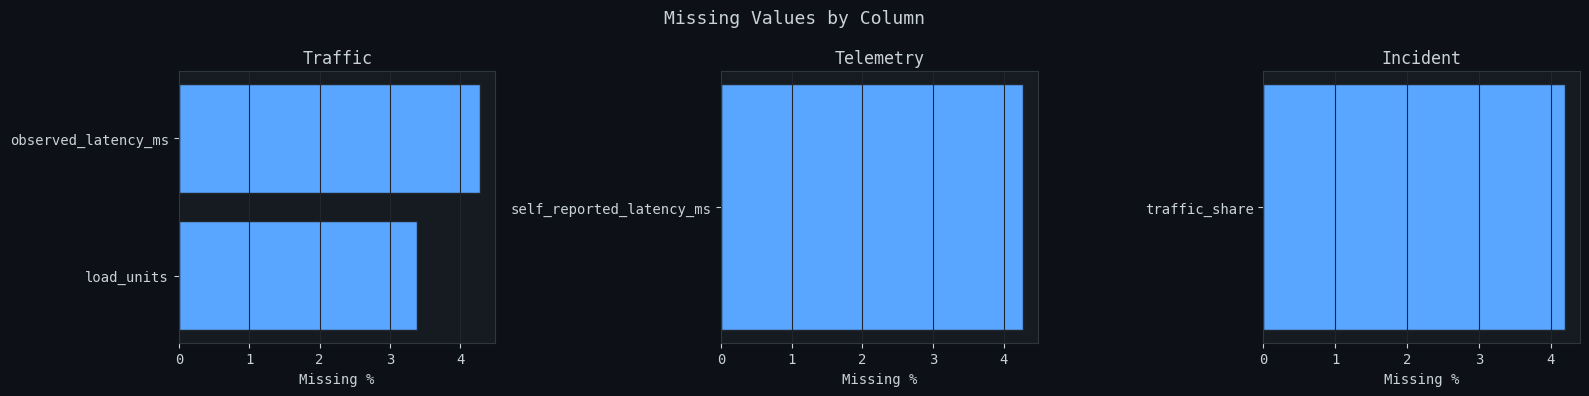


── Traffic missing values ──
load_units             203
observed_latency_ms    257

── Telemetry missing values ──
self_reported_latency_ms    256

── Incident missing values ──
traffic_share    252


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Missing Values by Column', fontsize=13)

for ax, (name, df) in zip(axes, datasets.items()):
    missing_pct = df.isna().mean() * 100
    missing_pct = missing_pct[missing_pct > 0]
    if missing_pct.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.barh(missing_pct.index, missing_pct.values, color=ACCENT, edgecolor='#21262d')
        ax.set_xlabel('Missing %')
    ax.set_title(name)
    ax.grid(axis='x')

plt.tight_layout()
plt.show()

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print(f'\n── {name} missing values ──')
    if missing.empty:
        print('  None')
    else:
        print(missing.to_string())

## 4. Duplicate Analysis

In [5]:
for name, df in datasets.items():
    total_dups = df.duplicated().sum()
    key_dups   = df.duplicated(subset=['link_id','tick']).sum()
    print(f'{name:<12}  full_row_dups={total_dups}  key(link_id,tick)_dups={key_dups}')

Traffic       full_row_dups=0  key(link_id,tick)_dups=0
Telemetry     full_row_dups=0  key(link_id,tick)_dups=0
Incident      full_row_dups=0  key(link_id,tick)_dups=0


## 5. Distribution Analysis

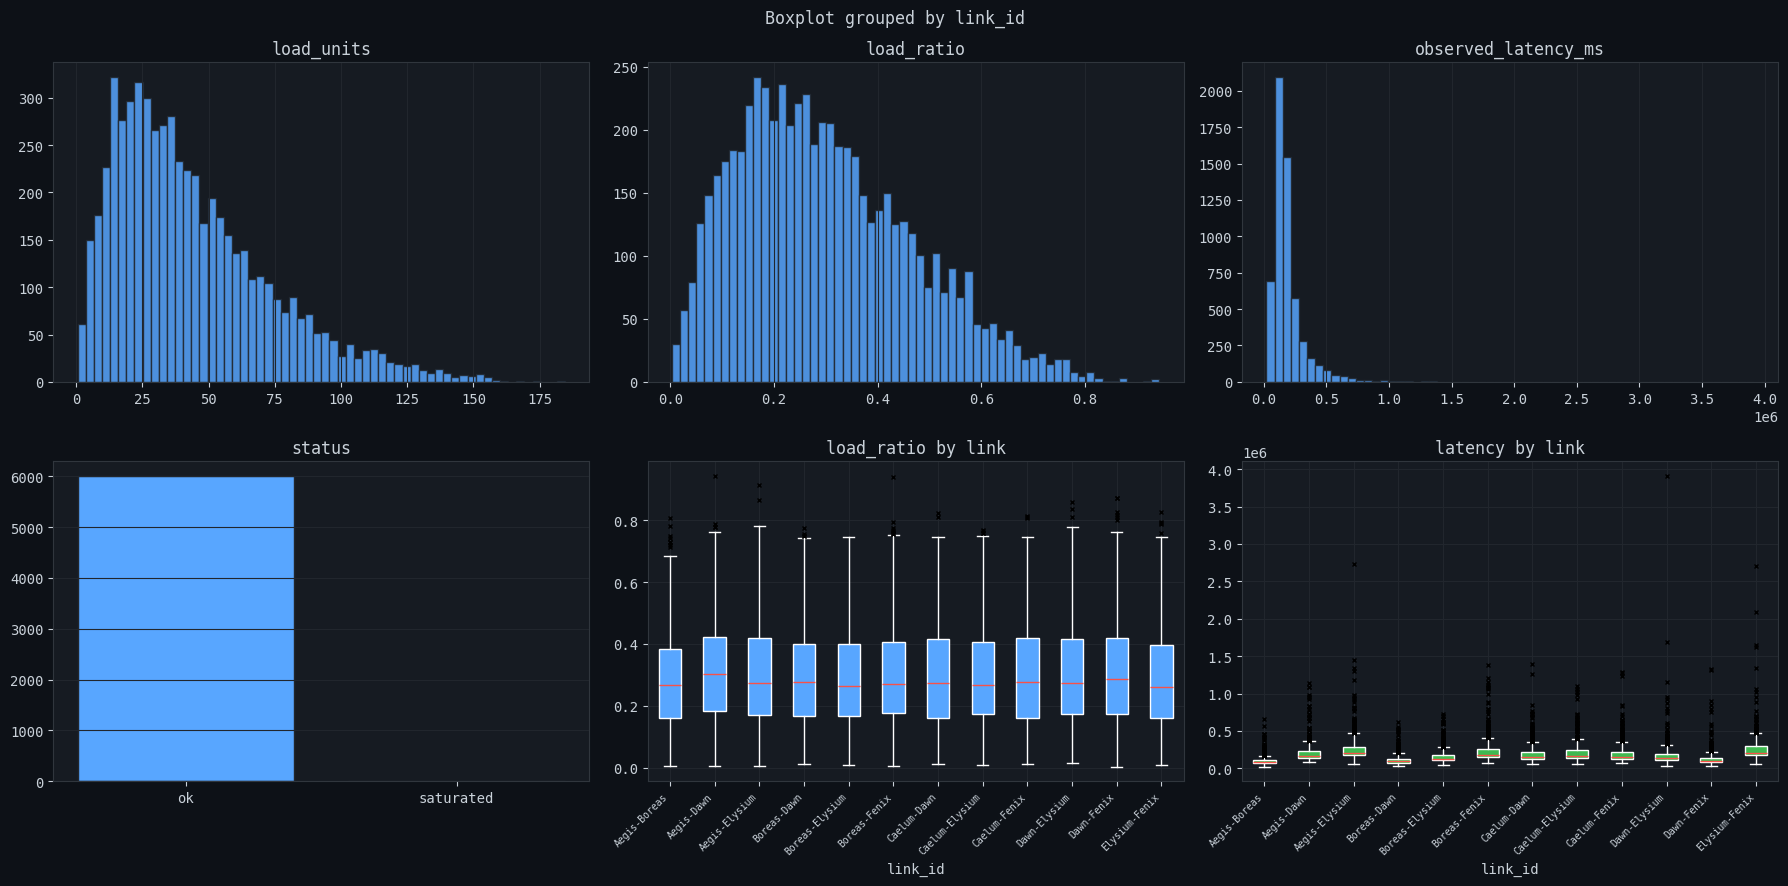

In [6]:
# ── Traffic distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Traffic Dataset – Feature Distributions', fontsize=14)

numeric_cols = ['load_units','load_ratio','observed_latency_ms']
for i, col in enumerate(numeric_cols):
    ax = axes[0, i]
    traffic[col].dropna().hist(bins=60, ax=ax, color=ACCENT, edgecolor='#21262d', alpha=0.85)
    ax.set_title(col); ax.grid(axis='y')

# status distribution
axes[1, 0].bar(*zip(*traffic['status'].value_counts().items()), color=[ACCENT,'#f85149'], edgecolor='#21262d')
axes[1, 0].set_title('status'); axes[1, 0].grid(axis='y')

# load_ratio box per link
traffic.boxplot(column='load_ratio', by='link_id', ax=axes[1, 1],
                patch_artist=True,
                boxprops=dict(facecolor=ACCENT, color='white'),
                medianprops=dict(color='#f85149'),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(marker='x', color='#e3b341', markersize=3))
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[1, 1].set_title('load_ratio by link')

# latency box per link
traffic.boxplot(column='observed_latency_ms', by='link_id', ax=axes[1, 2],
                patch_artist=True,
                boxprops=dict(facecolor='#3fb950', color='white'),
                medianprops=dict(color='#f85149'),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(marker='x', color='#e3b341', markersize=3))
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[1, 2].set_title('latency by link')

plt.tight_layout()
plt.show()

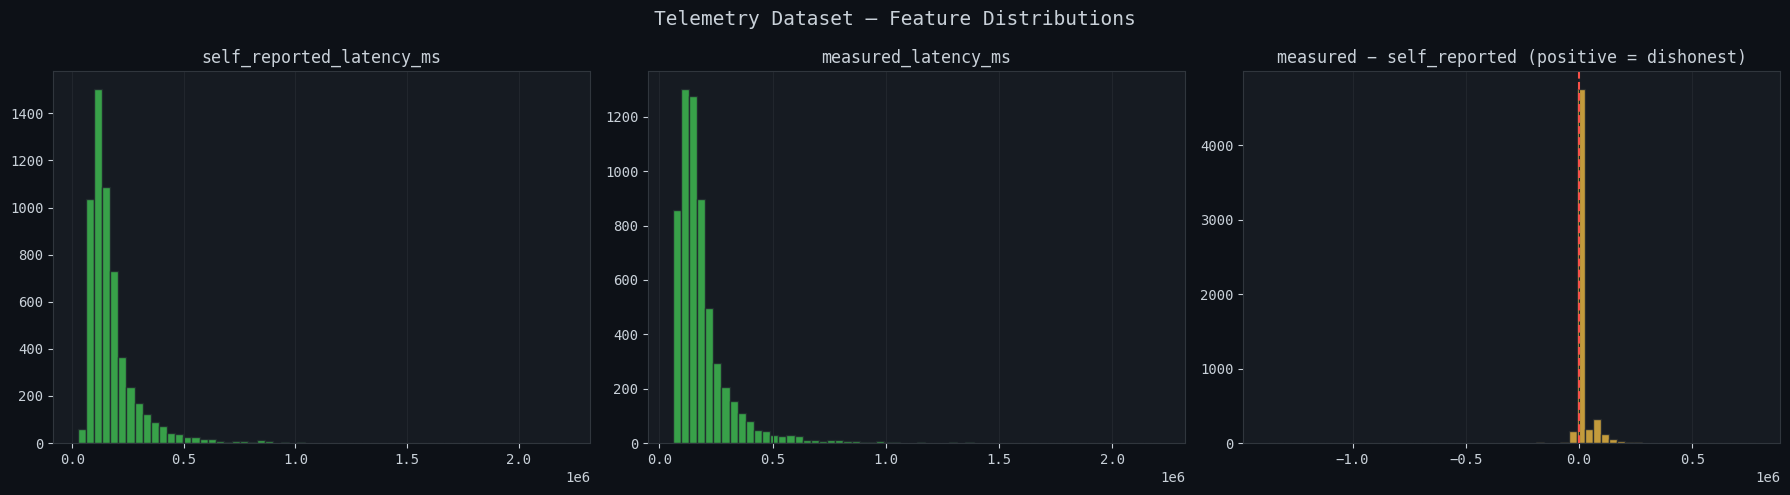

In [7]:
# ── Telemetry distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Telemetry Dataset – Feature Distributions', fontsize=14)

for ax, col in zip(axes, ['self_reported_latency_ms','measured_latency_ms']):
    telemetry[col].dropna().hist(bins=60, ax=ax, color='#3fb950', edgecolor='#21262d', alpha=0.85)
    ax.set_title(col); ax.grid(axis='y')

# Difference (trust indicator)
diff = telemetry['measured_latency_ms'] - telemetry['self_reported_latency_ms']
diff.dropna().hist(bins=60, ax=axes[2], color='#e3b341', edgecolor='#21262d', alpha=0.85)
axes[2].axvline(0, color='#f85149', linestyle='--')
axes[2].set_title('measured − self_reported (positive = dishonest)')
axes[2].grid(axis='y')
plt.tight_layout()
plt.show()

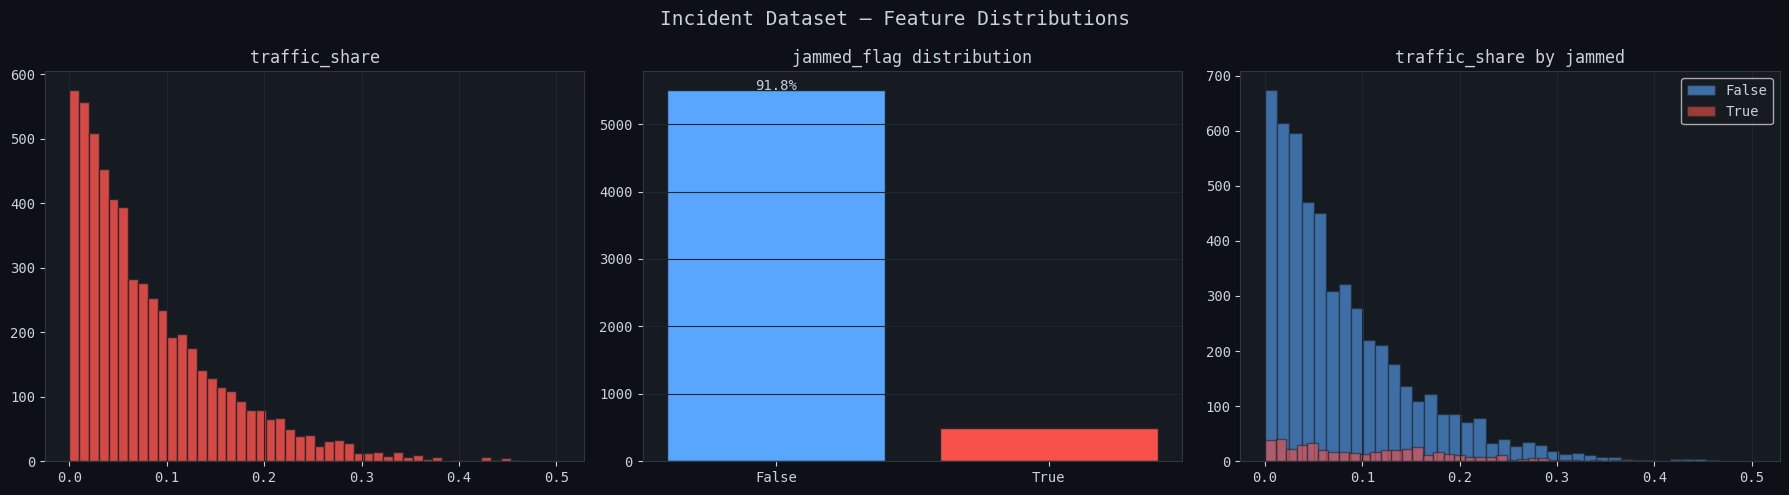

In [8]:
# ── Incident distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Incident Dataset – Feature Distributions', fontsize=14)

incident['traffic_share'].dropna().hist(bins=50, ax=axes[0], color='#f85149', edgecolor='#21262d', alpha=0.85)
axes[0].set_title('traffic_share'); axes[0].grid(axis='y')

jammed_counts = incident['jammed_flag'].value_counts()
axes[1].bar(jammed_counts.index.astype(str), jammed_counts.values,
            color=[ACCENT,'#f85149'], edgecolor='#21262d')
axes[1].set_title('jammed_flag distribution')
axes[1].text(0, jammed_counts.iloc[0], f'{jammed_counts.iloc[0]/len(incident)*100:.1f}%', ha='center')
axes[1].grid(axis='y')

# traffic_share by jammed
for label, grp in incident.groupby('jammed_flag'):
    grp['traffic_share'].hist(bins=40, ax=axes[2], alpha=0.6,
                              label=str(label),
                              color=ACCENT if not label else '#f85149',
                              edgecolor='#21262d')
axes[2].legend(); axes[2].set_title('traffic_share by jammed')
axes[2].grid(axis='y')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

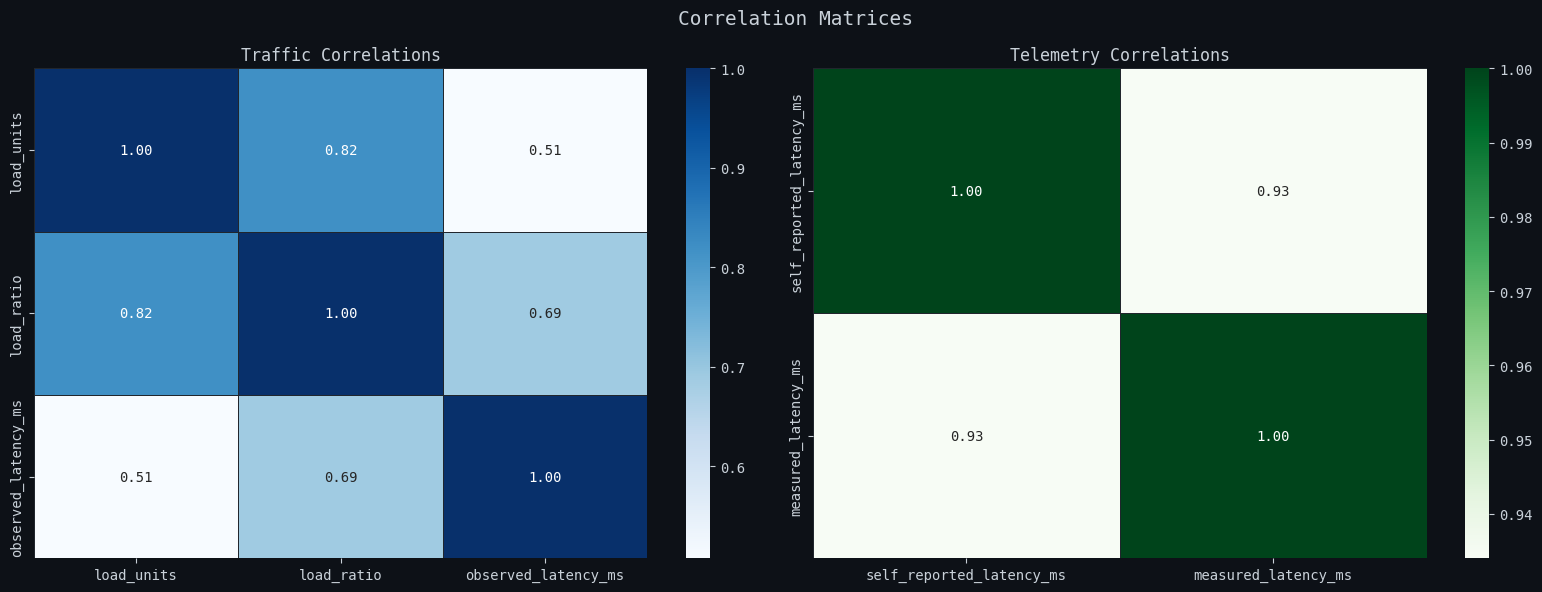

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Matrices', fontsize=14)

# Traffic
traffic_num = traffic[['load_units','load_ratio','observed_latency_ms']].dropna()
sns.heatmap(traffic_num.corr(), annot=True, fmt='.2f', cmap='Blues',
            ax=axes[0], linewidths=0.5, linecolor='#21262d')
axes[0].set_title('Traffic Correlations')

# Telemetry
tele_num = telemetry[['self_reported_latency_ms','measured_latency_ms']].dropna()
sns.heatmap(tele_num.corr(), annot=True, fmt='.2f', cmap='Greens',
            ax=axes[1], linewidths=0.5, linecolor='#21262d')
axes[1].set_title('Telemetry Correlations')
plt.tight_layout()
plt.show()

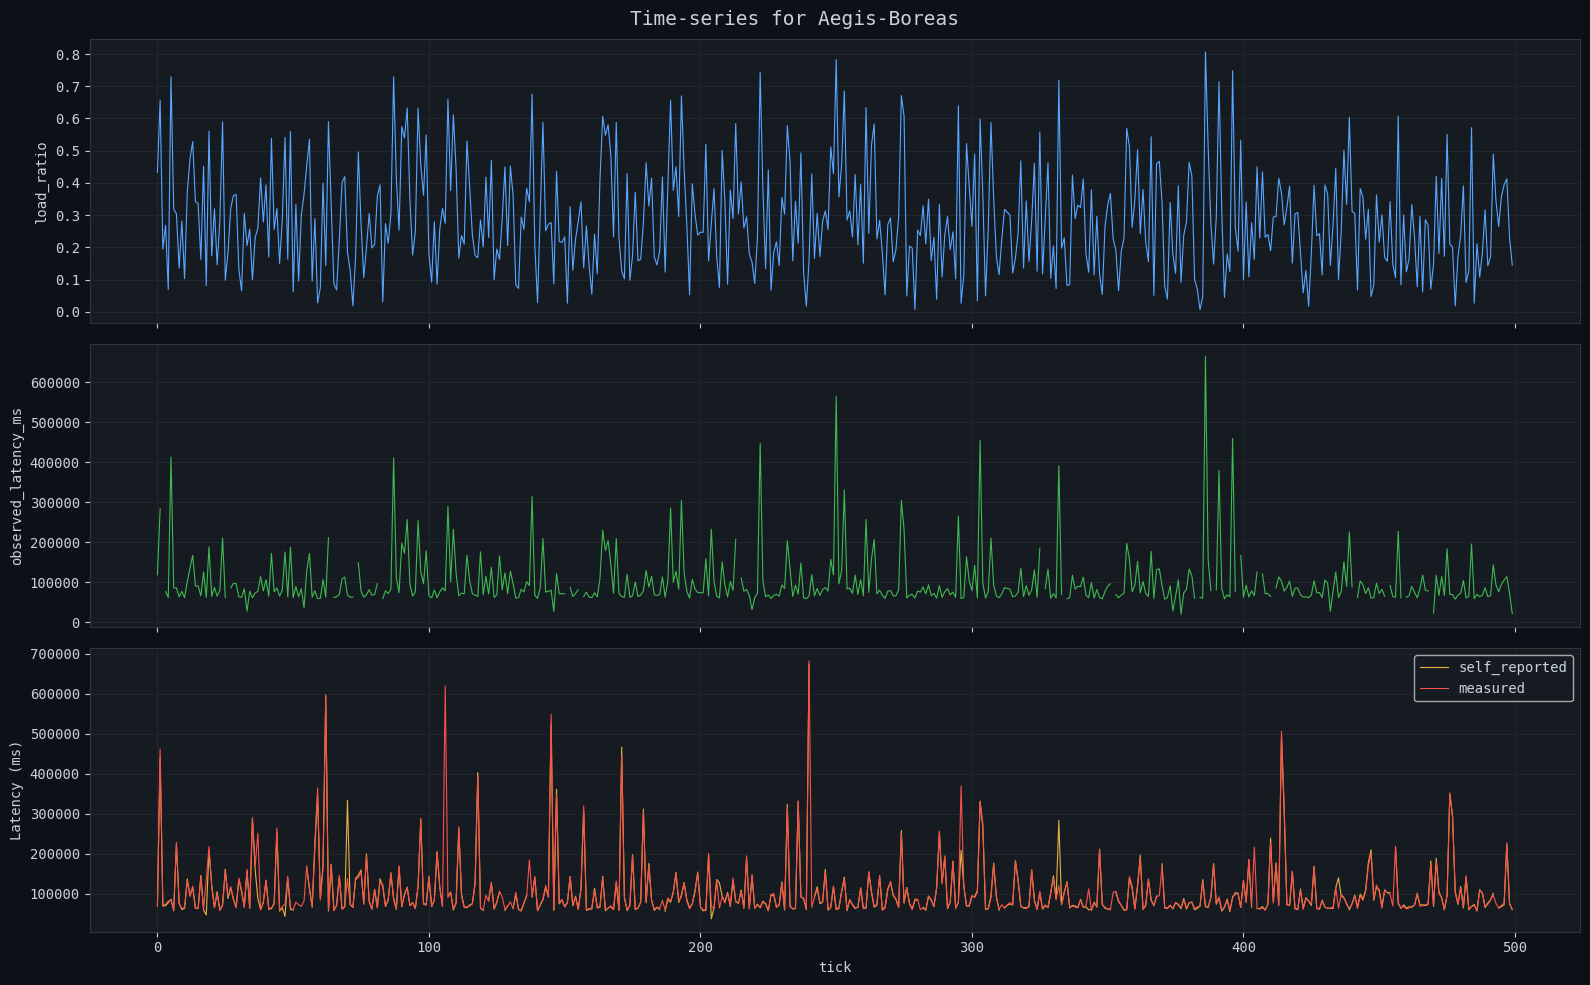

In [10]:
# ── Time-series for one link ───────────────────────────────────────────────
SAMPLE_LINK = 'Aegis-Boreas'
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Time-series for {SAMPLE_LINK}', fontsize=14)

t = traffic[traffic['link_id'] == SAMPLE_LINK]
axes[0].plot(t['tick'], t['load_ratio'], color=ACCENT, linewidth=0.8)
axes[0].set_ylabel('load_ratio'); axes[0].grid(True)

axes[1].plot(t['tick'], t['observed_latency_ms'], color='#3fb950', linewidth=0.8)
axes[1].set_ylabel('observed_latency_ms'); axes[1].grid(True)

tl = telemetry[telemetry['link_id'] == SAMPLE_LINK]
axes[2].plot(tl['tick'], tl['self_reported_latency_ms'], color='#e3b341',
             linewidth=0.8, label='self_reported')
axes[2].plot(tl['tick'], tl['measured_latency_ms'], color='#f85149',
             linewidth=0.8, label='measured')
axes[2].set_ylabel('Latency (ms)'); axes[2].legend(); axes[2].grid(True)
axes[2].set_xlabel('tick')

plt.tight_layout()
plt.show()

## 7. Outlier Detection

In [11]:
from scipy import stats

for name, df, col in [
    ('Traffic', traffic, 'observed_latency_ms'),
    ('Traffic', traffic, 'load_ratio'),
    ('Telemetry', telemetry, 'measured_latency_ms'),
    ('Incident', incident, 'traffic_share'),
]:
    series = df[col].dropna()
    z = np.abs(stats.zscore(series))
    outlier_count = (z > 3).sum()
    iqr = series.quantile(0.75) - series.quantile(0.25)
    iqr_outliers = ((series < series.quantile(0.25) - 1.5*iqr) |
                    (series > series.quantile(0.75) + 1.5*iqr)).sum()
    print(f'{name:10} | {col:30} | Z>3: {outlier_count:4d} | IQR: {iqr_outliers:4d}')

Traffic    | observed_latency_ms            | Z>3:  100 | IQR:  514
Traffic    | load_ratio                     | Z>3:   19 | IQR:   32
Telemetry  | measured_latency_ms            | Z>3:  114 | IQR:  473
Incident   | traffic_share                  | Z>3:   85 | IQR:  210


## 8. Jammed Rate per Link

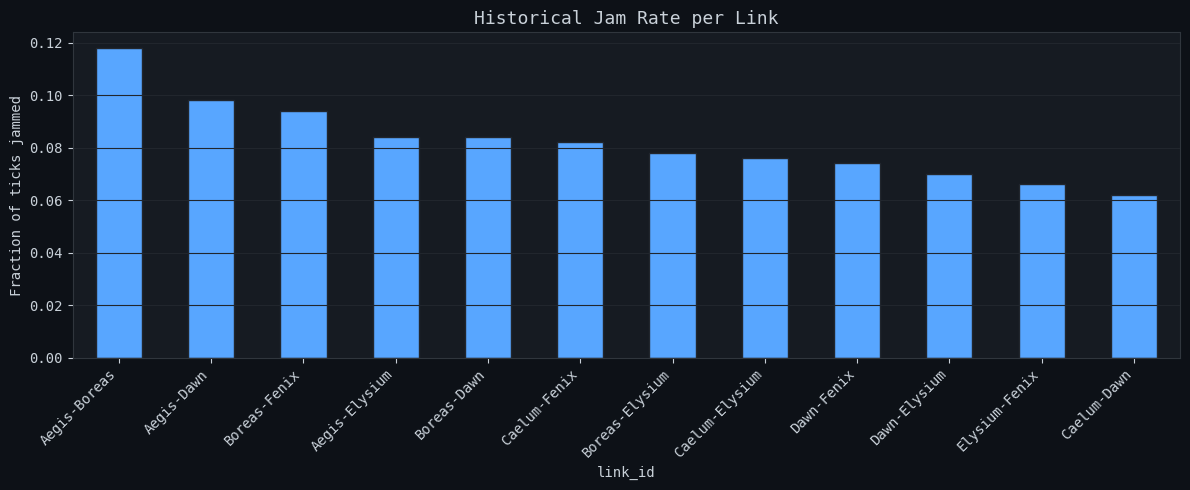

link_id
Aegis-Boreas      0.118
Aegis-Dawn        0.098
Boreas-Fenix      0.094
Aegis-Elysium     0.084
Boreas-Dawn       0.084
Caelum-Fenix      0.082
Boreas-Elysium    0.078
Caelum-Elysium    0.076
Dawn-Fenix        0.074
Dawn-Elysium      0.070
Elysium-Fenix     0.066
Caelum-Dawn       0.062


In [12]:
jammed_rate = incident.groupby('link_id')['jammed_flag'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
jammed_rate.plot.bar(ax=ax, color=ACCENT, edgecolor='#21262d')
ax.set_title('Historical Jam Rate per Link', fontsize=13)
ax.set_ylabel('Fraction of ticks jammed')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.show()
print(jammed_rate.to_string())

## 9. EDA Summary

| Finding | Detail |
|---|---|
| Traffic rows | ~6001 (12 links × ~500 ticks) |
| Missing in `load_units` | ~few % – safe to KNN impute |
| Missing `observed_latency_ms` | Present when status=saturated – **drop these rows** |
| Telemetry missing | `self_reported_latency_ms` has ~few % missing |
| Incident class balance | `jammed_flag` is imbalanced – some links have higher jam rates |
| Trust signal | Clear divergence between self-reported and measured latency on some links |
| No target leakage risk | All targets well-separated from input features |

> Proceed to **Notebook 02 – Data Preprocessing** to clean the datasets.